Task-1

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (10000, 28, 28)
x_test shape : (2000, 28, 28)
Flattened train shape: (10000, 784)
CNN-ready train shape: (10000, 28, 28, 1)


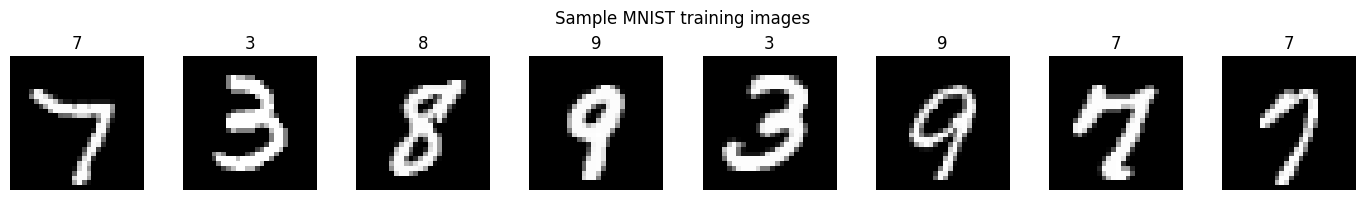

Saved exp7_data.npz — later tasks can load this instead of re-downloading MNIST.
Setup complete. compute_metrics(x_true, x_pred) is available for reuse in later tasks.


In [ ]:

!pip install scikit-image -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim
import time
np.random.seed(42)
tf.random.set_seed(42)
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0
N_TRAIN = 10000
N_TEST = 2000

idx_train = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train = x_train_full[idx_train]
y_train = y_train_full[idx_train]
x_test = x_test_full[idx_test]
y_test = y_test_full[idx_test]

print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)

x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))
x_train_cnn = x_train.reshape((-1, 28, 28, 1))
x_test_cnn = x_test.reshape((-1, 28, 28, 1))

print("Flattened train shape:", x_train_flat.shape)
print("CNN-ready train shape:", x_train_cnn.shape)
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i in range(8):
    axes[i].imshow(x_train[i], cmap="gray")
    axes[i].set_title(str(y_train[i]))
    axes[i].axis("off")
plt.suptitle("Sample MNIST training images")
plt.tight_layout()
plt.savefig("sample_mnist_images.png", dpi=150)
plt.show()
np.savez(
    "exp7_data.npz",
    x_train=x_train, x_test=x_test,
    y_train=y_train, y_test=y_test,
    x_train_flat=x_train_flat, x_test_flat=x_test_flat,
    x_train_cnn=x_train_cnn, x_test_cnn=x_test_cnn,
)
print("Saved exp7_data.npz — later tasks can load this instead of re-downloading MNIST.")
def compute_metrics(x_true, x_pred):
    """x_true, x_pred: arrays shaped (N, 28, 28) or (N, 28, 28, 1) or (N, 784), values in [0,1]."""
    x_true_flat = x_true.reshape(len(x_true), -1)
    x_pred_flat = x_pred.reshape(len(x_pred), -1)

    mse = np.mean((x_true_flat - x_pred_flat) ** 2)
    mae = np.mean(np.abs(x_true_flat - x_pred_flat))

    ssim_scores = []
    x_true_img = x_true.reshape(len(x_true), 28, 28)
    x_pred_img = x_pred.reshape(len(x_pred), 28, 28)
    for i in range(len(x_true_img)):
        s = ssim(x_true_img[i], x_pred_img[i], data_range=1.0)
        ssim_scores.append(s)
    mean_ssim = np.mean(ssim_scores)

    return mse, mae, mean_ssim

print("Setup complete. compute_metrics(x_true, x_pred) is available for reuse in later tasks.")

Task-2

Model: "fc_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 - 6s - 70ms/step - loss: 0.3425 - val_loss: 0.2530
Epoch 2/20
79/79 - 0s - 4ms/step - loss: 0.2359 - val_loss: 0.2163
Epoch 3/20
79/79 - 1s - 8ms/step - loss: 0.2013 - val_loss: 0.1875
Epoch 4/20
79/79 - 1s - 8ms/step - loss: 0.1815 - val_loss: 0.1730
Epoch 5/20
79/79 - 1s - 8ms/step - loss: 0.1696 - val_loss: 0.1649
Epoch 6/20
79/79 - 0s - 4ms/step - loss: 0.1624 - val_loss: 0.1579
Epoch 7/20
79/79 - 0s - 4ms/step - loss: 0.1561 - val_loss: 0.1521
Epoch 8/20
79/79 - 0s - 4ms/step - loss: 0.1510 - val_loss: 0.1477
Epoch 9/20
79/79 - 0s - 4ms/step - loss: 0.1471 - val_loss: 0.1447
Epoch 10/20
79/79 - 0s - 6ms/step - loss: 0.1445 - val_loss: 0.1425
Epoch 11/20
79/79 - 1s - 9ms/step - loss: 0.1424 - val_loss: 0.1407
Epoch 12/20
79/79 - 1s - 7ms/step - loss: 0.1407 - val_loss: 0.1392
Epoch 13/20
79/79 - 0s - 6ms/step - loss: 0.1392 - val_loss: 0.1380
Epoch 14/20
79/79 - 0s - 5ms/step - loss: 0.1378 - val_loss: 0.1365
Epoch 15/20
79/79 - 0s - 4ms/step - loss: 0.1361 - val_l

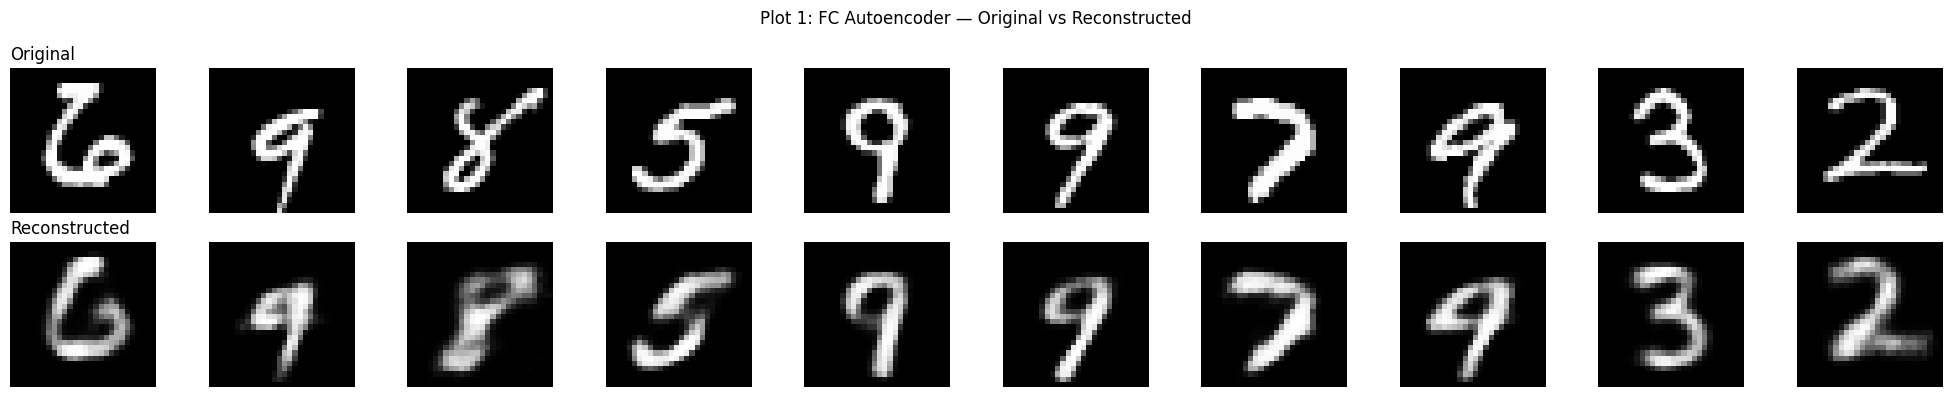

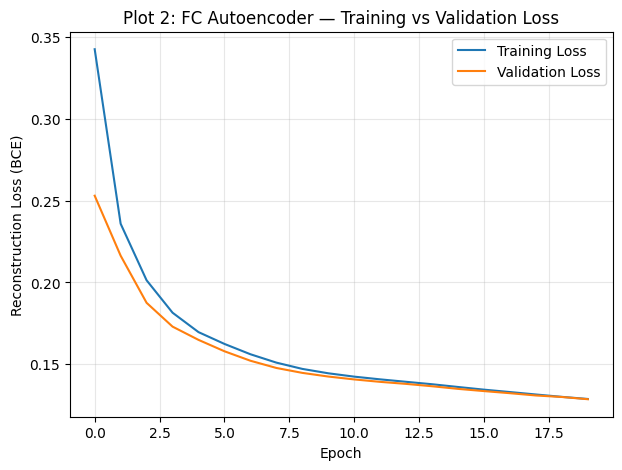


Required inference (Plot 1):
- Comment on preservation of digit shape.
- Comment on loss of fine details / blurring.
- Compare easy vs difficult samples (e.g., 1 vs 8).

Required inference (Plot 2):
- State whether train/val loss converge together (no overfitting)
  or diverge (val loss rising while train loss falls -> overfitting).



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

data = np.load("exp7_data.npz")
x_train_flat = data["x_train_flat"]
x_test_flat = data["x_test_flat"]
latent_dim = 16

inputs = keras.Input(shape=(784,), name="input")
x = layers.Dense(128, activation="relu")(inputs)
x = layers.Dense(32, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)
x = layers.Dense(32, activation="relu")(latent)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(784, activation="sigmoid")(x)

fc_autoencoder = keras.Model(inputs, outputs, name="fc_autoencoder")
fc_autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                        loss="binary_crossentropy")
fc_autoencoder.summary()
history = fc_autoencoder.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20,
    batch_size=128,
    verbose=2
)

fc_autoencoder.save("fc_autoencoder.keras")
np.save("fc_ae_history.npy", history.history)
n_display = 10
reconstructions = fc_autoencoder.predict(x_test_flat[:n_display])

fig, axes = plt.subplots(2, n_display, figsize=(20, 4))
for i in range(n_display):
    axes[0, i].imshow(x_test_flat[i].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructions[i].reshape(28, 28), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("Original", loc="left")
axes[1, 0].set_title("Reconstructed", loc="left")
plt.suptitle("Plot 1: FC Autoencoder — Original vs Reconstructed")
plt.tight_layout()
plt.savefig("plot1_fc_original_vs_reconstructed.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (BCE)")
plt.title("Plot 2: FC Autoencoder — Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("plot2_fc_loss_curves.png", dpi=150)
plt.show()

print("""
Required inference (Plot 1):
- Comment on preservation of digit shape.
- Comment on loss of fine details / blurring.
- Compare easy vs difficult samples (e.g., 1 vs 8).

Required inference (Plot 2):
- State whether train/val loss converge together (no overfitting)
  or diverge (val loss rising while train loss falls -> overfitting).
""")

Task-3

In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim

data = np.load("exp7_data.npz")
x_test_flat = data["x_test_flat"]

fc_autoencoder = keras.models.load_model("fc_autoencoder.keras")

reconstructions = fc_autoencoder.predict(x_test_flat, verbose=0)

def compute_metrics(x_true_flat, x_pred_flat):
    mse = np.mean((x_true_flat - x_pred_flat) ** 2)
    mae = np.mean(np.abs(x_true_flat - x_pred_flat))

    x_true_img = x_true_flat.reshape(-1, 28, 28)
    x_pred_img = x_pred_flat.reshape(-1, 28, 28)
    ssim_scores = [
        ssim(x_true_img[i], x_pred_img[i], data_range=1.0)
        for i in range(len(x_true_img))
    ]
    mean_ssim = np.mean(ssim_scores)
    return mse, mae, mean_ssim

test_mse, test_mae, mean_ssim = compute_metrics(x_test_flat, reconstructions)

print("=== Fully Connected Autoencoder — Test Set Metrics ===")
print(f"Test MSE  : {test_mse:.6f}")
print(f"Test MAE  : {test_mae:.6f}")
print(f"Mean SSIM : {mean_ssim:.6f}")

# Save for later comparison tasks
np.savez("fc_ae_metrics.npz", mse=test_mse, mae=test_mae, ssim=mean_ssim,
          n_params=fc_autoencoder.count_params())

print("\nSaved fc_ae_metrics.npz for use in the model comparison task.")

=== Fully Connected Autoencoder — Test Set Metrics ===
Test MSE  : 0.021939
Test MAE  : 0.058057
Mean SSIM : 0.754941

Saved fc_ae_metrics.npz for use in the model comparison task.


Task-4

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_feature_map (Conv2D)     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 - 9s - 113ms/step - loss: 0.2128 - val_loss: 0.0997
Epoch 2/20
79/79 - 1s - 9ms/step - loss: 0.0912 - val_loss: 0.0847
Epoch 3/20
79/79 - 1s - 10ms/step - loss: 0.0823 - val_loss: 0.0801
Epoch 4/20
79/79 - 1s - 8ms/step - loss: 0.0788 - val_loss: 0.0777
Epoch 5/20
79/79 - 1s - 9ms/step - loss: 0.0764 - val_loss: 0.0768
Epoch 6/20
79/79 - 1s - 9ms/step - loss: 0.0749 - val_loss: 0.0748
Epoch 7/20
79/79 - 1s - 14ms/step - loss: 0.0738 - val_loss: 0.0750
Epoch 8/20
79/79 - 1s - 8ms/step - loss: 0.0730 - val_loss: 0.0722
Epoch 9/20
79/79 - 1s - 8ms/step - loss: 0.0722 - val_loss: 0.0732
Epoch 10/20
79/79 - 1s - 8ms/step - loss: 0.0718 - val_loss: 0.0719
Epoch 11/20
79/79 - 1s - 8ms/step - loss: 0.0713 - val_loss: 0.0705
Epoch 12/20
79/79 - 1s - 8ms/step - loss: 0.0708 - val_loss: 0.0714
Epoch 13/20
79/79 - 1s - 8ms/step - loss: 0.0705 - val_loss: 0.0703
Epoch 14/20
79/79 - 1s - 9ms/step - loss: 0.0701 - val_loss: 0.0700
Epoch 15/20
79/79 - 1s - 9ms/step - loss: 0.0698 - va

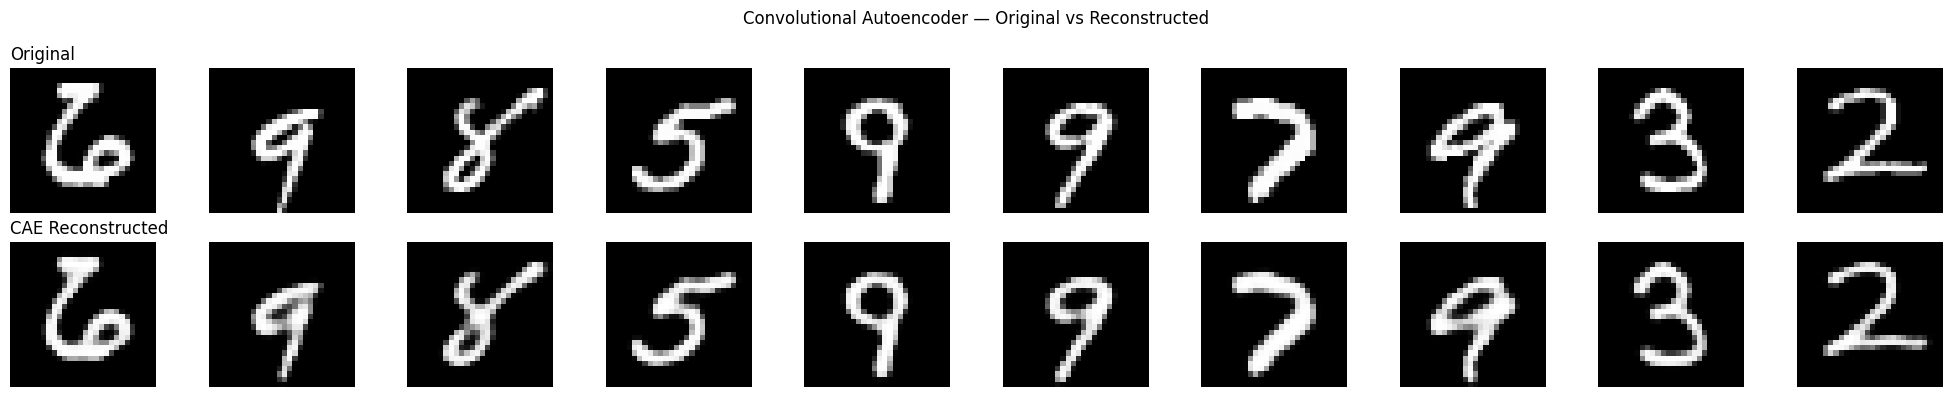

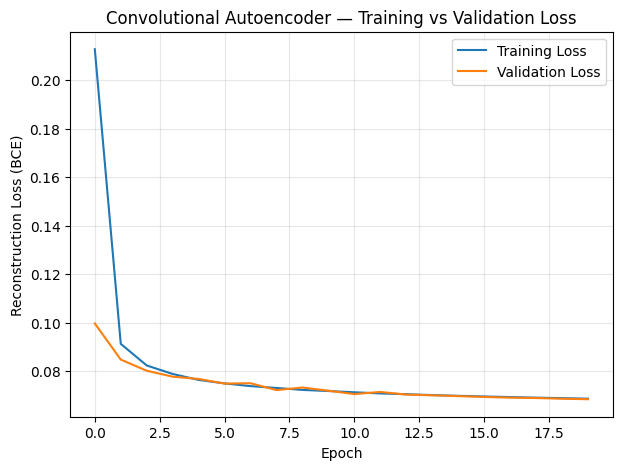

Training time: 23.4 s
Total parameters: 74497


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time

np.random.seed(42)
tf.random.set_seed(42)

data = np.load("exp7_data.npz")
x_train_cnn = data["x_train_cnn"]
x_test_cnn = data["x_test_cnn"]
inputs = keras.Input(shape=(28, 28, 1), name="input")

# Encoder
x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D(2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)
latent = layers.Conv2D(64, 3, activation="relu", padding="same", name="latent_feature_map")(x)

# Decoder
x = layers.UpSampling2D(2)(latent)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)
outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

conv_autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder")
conv_autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                          loss="binary_crossentropy")
conv_autoencoder.summary()

start = time.time()
history = conv_autoencoder.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20,
    batch_size=128,
    verbose=2
)
train_time = time.time() - start

conv_autoencoder.save("conv_autoencoder.keras")
np.save("cae_history.npy", history.history)
np.save("cae_train_time.npy", train_time)

n_display = 10
reconstructions = conv_autoencoder.predict(x_test_cnn[:n_display])

fig, axes = plt.subplots(2, n_display, figsize=(20, 4))
for i in range(n_display):
    axes[0, i].imshow(x_test_cnn[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructions[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("Original", loc="left")
axes[1, 0].set_title("CAE Reconstructed", loc="left")
plt.suptitle("Convolutional Autoencoder — Original vs Reconstructed")
plt.tight_layout()
plt.savefig("cae_original_vs_reconstructed.png", dpi=150)
plt.show()
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (BCE)")
plt.title("Convolutional Autoencoder — Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("cae_loss_curves.png", dpi=150)
plt.show()

print(f"Training time: {train_time:.1f} s")
print(f"Total parameters: {conv_autoencoder.count_params()}")

Task-5

=== Model Comparison: FC-AE vs CAE ===
Model               MSE         MAE         SSIM        Params      
Fully Connected AE  0.021939    0.058057    0.754941    211040      
Convolutional AE    0.002561    0.015308    0.973854    74497       


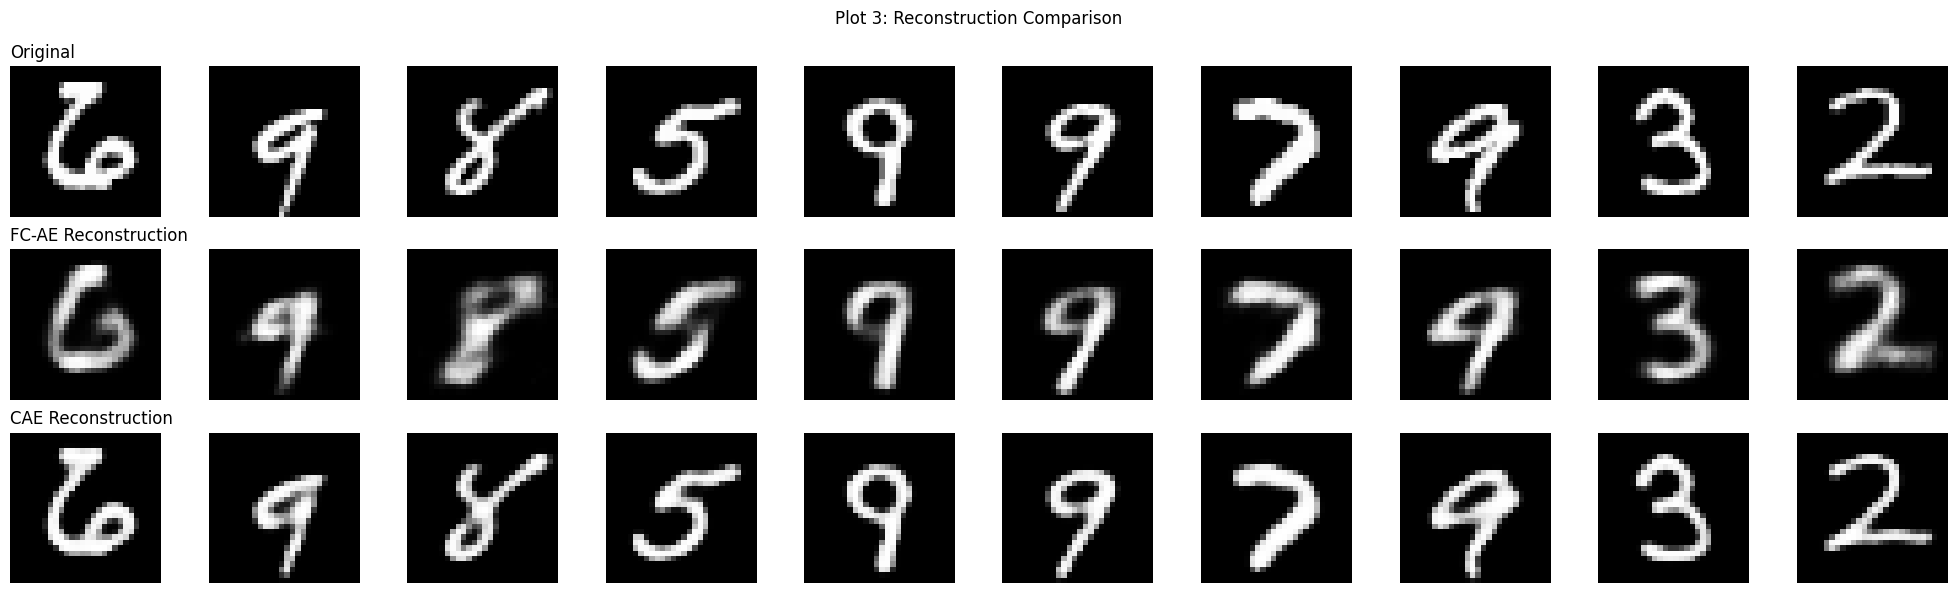


Required inference:
- Discuss how preserving spatial locality through convolution affects
  reconstruction quality (typically CAE achieves lower MSE/MAE and
  higher SSIM than the flattened FC-AE, since conv layers exploit
  local pixel correlations that flattening destroys).



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim

data = np.load("exp7_data.npz")
x_test_flat = data["x_test_flat"]
x_test_cnn = data["x_test_cnn"]

fc_autoencoder = keras.models.load_model("fc_autoencoder.keras")
conv_autoencoder = keras.models.load_model("conv_autoencoder.keras")

def compute_metrics_img(x_true_img, x_pred_img):
    mse = np.mean((x_true_img - x_pred_img) ** 2)
    mae = np.mean(np.abs(x_true_img - x_pred_img))
    ssim_scores = [
        ssim(x_true_img[i].squeeze(), x_pred_img[i].squeeze(), data_range=1.0)
        for i in range(len(x_true_img))
    ]
    return mse, mae, np.mean(ssim_scores)

fc_recon = fc_autoencoder.predict(x_test_flat, verbose=0).reshape(-1, 28, 28, 1)
cae_recon = conv_autoencoder.predict(x_test_cnn, verbose=0)

fc_mse, fc_mae, fc_ssim = compute_metrics_img(x_test_cnn, fc_recon)
cae_mse, cae_mae, cae_ssim = compute_metrics_img(x_test_cnn, cae_recon)

print("=== Model Comparison: FC-AE vs CAE ===")
print(f"{'Model':<20}{'MSE':<12}{'MAE':<12}{'SSIM':<12}{'Params':<12}")
print(f"{'Fully Connected AE':<20}{fc_mse:<12.6f}{fc_mae:<12.6f}{fc_ssim:<12.6f}{fc_autoencoder.count_params():<12}")
print(f"{'Convolutional AE':<20}{cae_mse:<12.6f}{cae_mae:<12.6f}{cae_ssim:<12.6f}{conv_autoencoder.count_params():<12}")

n_display = 10
fig, axes = plt.subplots(3, n_display, figsize=(20, 6))
for i in range(n_display):
    axes[0, i].imshow(x_test_cnn[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(fc_recon[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[2, i].imshow(cae_recon[i].squeeze(), cmap="gray")
    axes[2, i].axis("off")
axes[0, 0].set_title("Original", loc="left")
axes[1, 0].set_title("FC-AE Reconstruction", loc="left")
axes[2, 0].set_title("CAE Reconstruction", loc="left")
plt.suptitle("Plot 3: Reconstruction Comparison")
plt.tight_layout()
plt.savefig("plot3_fc_vs_cae_comparison.png", dpi=150)
plt.show()

np.savez("fc_vs_cae_metrics.npz",
          fc_mse=fc_mse, fc_mae=fc_mae, fc_ssim=fc_ssim,
          cae_mse=cae_mse, cae_mae=cae_mae, cae_ssim=cae_ssim)

print("""
Required inference:
- Discuss how preserving spatial locality through convolution affects
  reconstruction quality (typically CAE achieves lower MSE/MAE and
  higher SSIM than the flattened FC-AE, since conv layers exploit
  local pixel correlations that flattening destroys).
""")

Task-6

Model: "denoising_cae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 - 6s - 71ms/step - loss: 0.2622 - val_loss: 0.1249
Epoch 2/20
79/79 - 1s - 9ms/step - loss: 0.1086 - val_loss: 0.0966
Epoch 3/20
79/79 - 1s - 8ms/step - loss: 0.0931 - val_loss: 0.0887
Epoch 4/20
79/79 - 1s - 9ms/step - loss: 0.0877 - val_loss: 0.0847
Epoch 5/20
79/79 - 1s - 9ms/step - loss: 0.0845 - val_loss: 0.0823
Epoch 6/20
79/79 - 1s - 10ms/step - loss: 0.0824 - val_loss: 0.0807
Epoch 7/20
79/79 - 1s - 9ms/step - loss: 0.0809 - val_loss: 0.0795
Epoch 8/20
79/79 - 1s - 8ms/step - loss: 0.0799 - val_loss: 0.0789
Epoch 9/20
79/79 - 1s - 8ms/step - loss: 0.0791 - val_loss: 0.0781
Epoch 10/20
79/79 - 1s - 9ms/step - loss: 0.0784 - val_loss: 0.0777
Epoch 11/20
79/79 - 1s - 9ms/step - loss: 0.0779 - val_loss: 0.0772
Epoch 12/20
79/79 - 1s - 8ms/step - loss: 0.0774 - val_loss: 0.0767
Epoch 13/20
79/79 - 1s - 9ms/step - loss: 0.0770 - val_loss: 0.0764
Epoch 14/20
79/79 - 1s - 8ms/step - loss: 0.0766 - val_loss: 0.0761
Epoch 15/20
79/79 - 1s - 8ms/step - loss: 0.0763 - val_

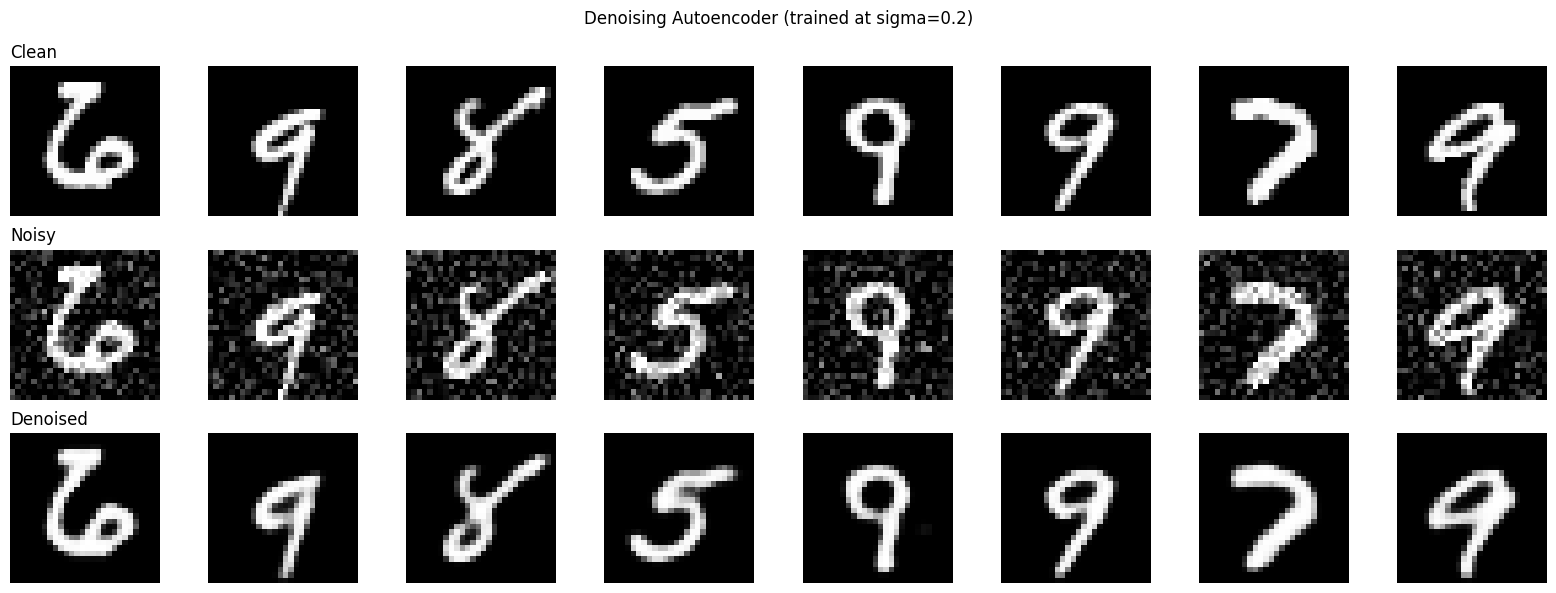

Saved denoising_cae.keras and helper noise functions (re-defined in Task 7).


In [ ]:
# =========================================================
# Experiment 7 - Task 6: Denoising Autoencoder (Sections 12 & 13)
# Requires: exp7_data.npz from Task 1
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

data = np.load("exp7_data.npz")
x_train_cnn = data["x_train_cnn"]
x_test_cnn = data["x_test_cnn"]

# -----------------------------
# Noise functions
# -----------------------------
def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(0, sigma, images.shape)
    return np.clip(noisy, 0.0, 1.0).astype("float32")

def add_salt_pepper_noise(images, p):
    noisy = images.copy()
    mask = np.random.rand(*images.shape)
    noisy[mask < p / 2] = 0.0          # pepper
    noisy[mask > 1 - p / 2] = 1.0      # salt
    return noisy.astype("float32")

# -----------------------------
# Build denoising CAE (same architecture as Task 4's CAE)
# -----------------------------
def build_denoising_cae():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    model = keras.Model(inputs, outputs, name="denoising_cae")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return model

# -----------------------------
# Train the denoising autoencoder using Gaussian noise, sigma=0.2
# (target remains the CLEAN image)
# -----------------------------
TRAIN_SIGMA = 0.2
x_train_noisy = add_gaussian_noise(x_train_cnn, TRAIN_SIGMA)
x_test_noisy = add_gaussian_noise(x_test_cnn, TRAIN_SIGMA)

denoising_cae = build_denoising_cae()
denoising_cae.summary()

history = denoising_cae.fit(
    x_train_noisy, x_train_cnn,          # noisy input -> clean target
    validation_data=(x_test_noisy, x_test_cnn),
    epochs=20,
    batch_size=128,
    verbose=2
)

denoising_cae.save("denoising_cae.keras")
np.save("denoising_cae_history.npy", history.history)

# -----------------------------
# Quick visual check
# -----------------------------
n_display = 8
denoised = denoising_cae.predict(x_test_noisy[:n_display])

fig, axes = plt.subplots(3, n_display, figsize=(16, 6))
for i in range(n_display):
    axes[0, i].imshow(x_test_cnn[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[2, i].imshow(denoised[i].squeeze(), cmap="gray")
    axes[2, i].axis("off")
axes[0, 0].set_title("Clean", loc="left")
axes[1, 0].set_title("Noisy", loc="left")
axes[2, 0].set_title("Denoised", loc="left")
plt.suptitle(f"Denoising Autoencoder (trained at sigma={TRAIN_SIGMA})")
plt.tight_layout()
plt.savefig("denoising_quick_check.png", dpi=150)
plt.show()

print("Saved denoising_cae.keras and helper noise functions (re-defined in Task 7).")

Task-7

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


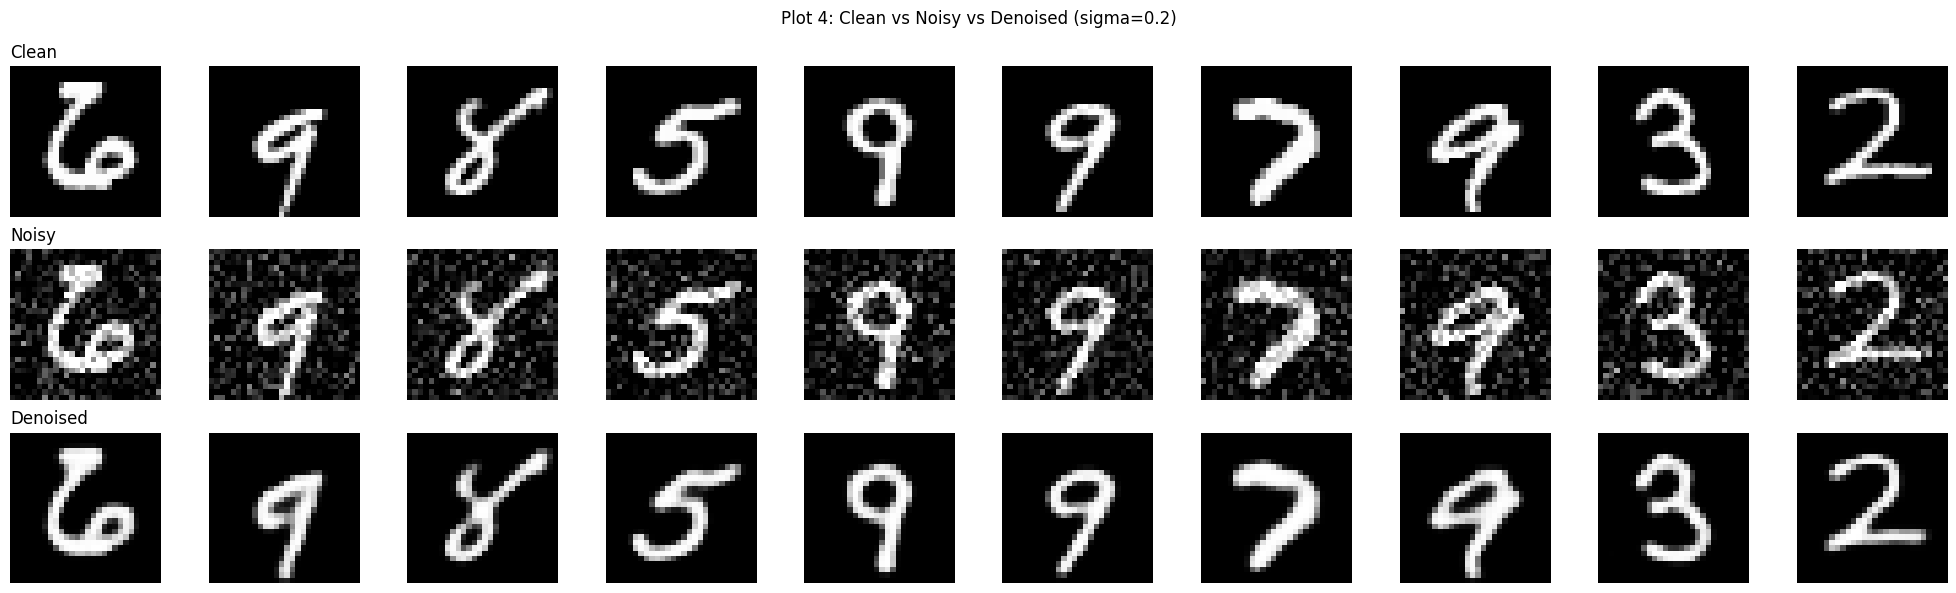

sigma=0.1 -> MSE=0.003511, MAE=0.017354, SSIM=0.961892
sigma=0.2 -> MSE=0.004451, MAE=0.020670, SSIM=0.948907
sigma=0.3 -> MSE=0.006691, MAE=0.027823, SSIM=0.894538


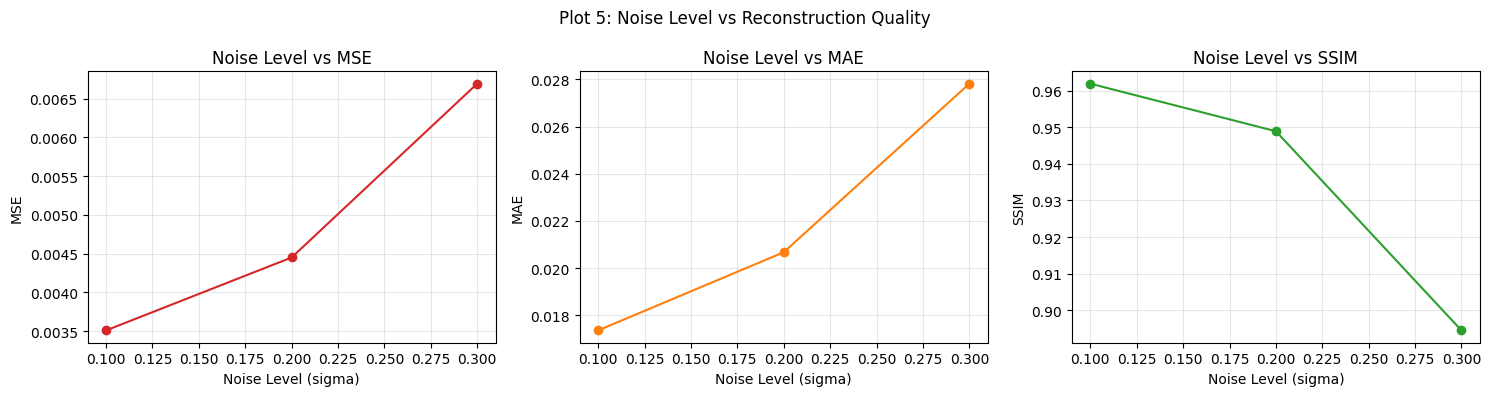


Noise Level | MSE | MAE | SSIM
0.1         0.003511    0.017354    0.961892    
0.2         0.004451    0.020670    0.948907    
0.3         0.006691    0.027823    0.894538    

Required inference:
- Explain how increasing corruption (higher sigma) affects reconstruction
  quality: MSE/MAE typically rise and SSIM falls as sigma increases.
- State whether the model still recovers the major digit structure at
  the highest noise level tested.



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)

data = np.load("exp7_data.npz")
x_test_cnn = data["x_test_cnn"]

denoising_cae = keras.models.load_model("denoising_cae.keras")

def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(0, sigma, images.shape)
    return np.clip(noisy, 0.0, 1.0).astype("float32")

def compute_metrics_img(x_true_img, x_pred_img):
    mse = np.mean((x_true_img - x_pred_img) ** 2)
    mae = np.mean(np.abs(x_true_img - x_pred_img))
    ssim_scores = [
        ssim(x_true_img[i].squeeze(), x_pred_img[i].squeeze(), data_range=1.0)
        for i in range(len(x_true_img))
    ]
    return mse, mae, np.mean(ssim_scores)

sigma_display = 0.2
x_test_noisy_display = add_gaussian_noise(x_test_cnn, sigma_display)
denoised_display = denoising_cae.predict(x_test_noisy_display)

n_display = 10
fig, axes = plt.subplots(3, n_display, figsize=(20, 6))
for i in range(n_display):
    axes[0, i].imshow(x_test_cnn[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_test_noisy_display[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[2, i].imshow(denoised_display[i].squeeze(), cmap="gray")
    axes[2, i].axis("off")
axes[0, 0].set_title("Clean", loc="left")
axes[1, 0].set_title("Noisy", loc="left")
axes[2, 0].set_title("Denoised", loc="left")
plt.suptitle(f"Plot 4: Clean vs Noisy vs Denoised (sigma={sigma_display})")
plt.tight_layout()
plt.savefig("plot4_clean_noisy_denoised.png", dpi=150)
plt.show()
noise_levels = [0.1, 0.2, 0.3]
results = []

for sigma in noise_levels:
    x_test_noisy = add_gaussian_noise(x_test_cnn, sigma)
    denoised = denoising_cae.predict(x_test_noisy, verbose=0)
    mse, mae, mean_ssim = compute_metrics_img(x_test_cnn, denoised)
    results.append((sigma, mse, mae, mean_ssim))
    print(f"sigma={sigma:.1f} -> MSE={mse:.6f}, MAE={mae:.6f}, SSIM={mean_ssim:.6f}")

sigmas = [r[0] for r in results]
mses = [r[1] for r in results]
maes = [r[2] for r in results]
ssims = [r[3] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(sigmas, mses, marker="o", color="tab:red")
axes[0].set_xlabel("Noise Level (sigma)")
axes[0].set_ylabel("MSE")
axes[0].set_title("Noise Level vs MSE")
axes[0].grid(alpha=0.3)

axes[1].plot(sigmas, maes, marker="o", color="tab:orange")
axes[1].set_xlabel("Noise Level (sigma)")
axes[1].set_ylabel("MAE")
axes[1].set_title("Noise Level vs MAE")
axes[1].grid(alpha=0.3)

axes[2].plot(sigmas, ssims, marker="o", color="tab:green")
axes[2].set_xlabel("Noise Level (sigma)")
axes[2].set_ylabel("SSIM")
axes[2].set_title("Noise Level vs SSIM")
axes[2].grid(alpha=0.3)

plt.suptitle("Plot 5: Noise Level vs Reconstruction Quality")
plt.tight_layout()
plt.savefig("plot5_noise_vs_quality.png", dpi=150)
plt.show()

print("\nNoise Level | MSE | MAE | SSIM")
for sigma, mse, mae, s in results:
    print(f"{sigma:<12}{mse:<12.6f}{mae:<12.6f}{s:<12.6f}")

print("""
Required inference:
- Explain how increasing corruption (higher sigma) affects reconstruction
  quality: MSE/MAE typically rise and SSIM falls as sigma increases.
- State whether the model still recovers the major digit structure at
  the highest noise level tested.
""")

Task-8

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │    200,768 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 219,844 (858.77 KB)

 Trainable params: 219,844 (858.77 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
79/79 - 10s - 126ms/step - kl_loss: 2.9833 - loss: 289.1957 - reconstruction_loss: 286.2125
Epoch 2/30
79/79 - 1s - 9ms/step - kl_loss: 3.0449 - loss: 200.9710 - reconstruction_loss: 197.9261
Epoch 3/30
79/79 - 1s - 8ms/step - kl_loss: 2.7534 - loss: 194.4588 - reconstruction_loss: 191.7054
Epoch 4/30
79/79 - 1s - 10ms/step - kl_loss: 2.6413 - loss: 191.7616 - reconstruction_loss: 189.1203
Epoch 5/30
79/79 - 1s - 6ms/step - kl_loss: 4.1247 - loss: 181.4393 - reconstruction_loss: 177.3145
Epoch 6/30
79/79 - 1s - 9ms/step - kl_loss: 4.2763 - loss: 178.0419 - reconstruction_loss: 173.7655
Epoch 7/30
79/79 - 1s - 9ms/step - kl_loss: 4.4236 - loss: 176.2194 - reconstruction_loss: 171.7958
Epoch 8/30
79/79 - 1s - 8ms/step - kl_loss: 4.4961 - loss: 174.4315 - reconstruction_loss: 169.9354
Epoch 9/30
79/79 - 1s - 8ms/step - kl_loss: 4.6202 - loss: 171.7695 - reconstruction_loss: 167.1492
Epoch 10/30
79/79 - 1s - 14ms/step - kl_loss: 4.7348 - loss: 169.2523 - reconstruction_loss: 164

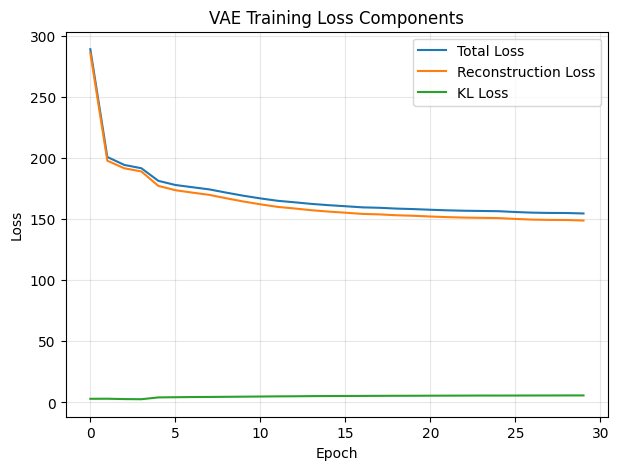

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

data = np.load("exp7_data.npz")
x_train_cnn = data["x_train_cnn"]
x_test_cnn = data["x_test_cnn"]
y_test = data["y_test"]

LATENT_DIM = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

latent_inputs = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

history = vae.fit(
    x_train_cnn,
    epochs=30,
    batch_size=128,
    verbose=2
)

metrics = vae.evaluate(x_test_cnn, batch_size=128, verbose=0, return_dict=True)
print("Final test-set metrics:", metrics)

encoder.save("vae_encoder.keras")
decoder.save("vae_decoder.keras")
np.save("vae_history.npy", history.history)
np.save("vae_val_metrics.npy", metrics)

print("VAE training complete. Encoder and decoder saved separately.")
print(f"Final total loss: {history.history['loss'][-1]:.3f}")
print(f"Final reconstruction loss: {history.history['reconstruction_loss'][-1]:.3f}")
print(f"Final KL loss: {history.history['kl_loss'][-1]:.3f}")

# Quick loss curve
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Total Loss")
plt.plot(history.history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history.history["kl_loss"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss Components")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("vae_training_loss_components.png", dpi=150)
plt.show()

Task-9

In [ ]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0

N_TRAIN, N_TEST = 10000, 2000
x_train = x_train_full[:N_TRAIN]
y_train = y_train_full[:N_TRAIN]
x_test = x_test_full[:N_TEST]
y_test = y_test_full[:N_TEST]

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("Train:", x_train_flat.shape, x_train_cnn.shape)
print("Test :", x_test_flat.shape, x_test_cnn.shape)

Train: (10000, 784) (10000, 28, 28, 1)
Test : (2000, 784) (2000, 28, 28, 1)


In [ ]:
def evaluate_reconstruction(x_true, x_pred):
    """x_true, x_pred: arrays of shape (N,28,28), (N,28,28,1) or (N,784), values in [0,1]."""
    x_true_flat = x_true.reshape(len(x_true), -1)
    x_pred_flat = x_pred.reshape(len(x_pred), -1)
    mse = np.mean((x_true_flat - x_pred_flat) ** 2)
    mae = np.mean(np.abs(x_true_flat - x_pred_flat))
    x_true_img = x_true.reshape(len(x_true), 28, 28)
    x_pred_img = x_pred.reshape(len(x_pred), 28, 28)
    ssim_scores = [ssim(x_true_img[i], x_pred_img[i], data_range=1.0) for i in range(len(x_true_img))]
    return {"MSE": mse, "MAE": mae, "SSIM": np.mean(ssim_scores)}

In [ ]:
def build_fc_autoencoder(latent_dim=16):
    inputs = keras.Input(shape=(784,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(latent)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(784, activation="sigmoid")(x)
    autoencoder = keras.Model(inputs, outputs, name="fc_autoencoder")
    encoder = keras.Model(inputs, latent, name="fc_encoder")
    return autoencoder, encoder

fc_autoencoder, fc_encoder = build_fc_autoencoder(latent_dim=16)
fc_autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
fc_autoencoder.summary()

fc_history = fc_autoencoder.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20, batch_size=128, verbose=1
)

Model: "fc_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.3521 - val_loss: 0.2534
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2419 - val_loss: 0.2233
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2089 - val_loss: 0.1940
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1881 - val_loss: 0.1826
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1745 - val_loss: 0.1702
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1642 - val_loss: 0.1624
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1558 - val_loss: 0.1544
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1489 - val_loss: 0.1484
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1438 - val_loss: 0.1443
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1400 - val_loss: 0.1413
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1371 - val_loss: 0.1394
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1350 - val_l

In [ ]:
fc_test_recon = fc_autoencoder.predict(x_test_flat)
fc_metrics = evaluate_reconstruction(x_test_flat, fc_test_recon)
fc_metrics["Parameters"] = fc_autoencoder.count_params()
print("Fully Connected AE metrics:")
for k, v in fc_metrics.items():
    print(f"  {k}: {v}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fully Connected AE metrics:
  MSE: 0.022446153685450554
  MAE: 0.05902570113539696
  SSIM: 0.7355998980278909
  Parameters: 211040


Task-10

In [ ]:
def build_conv_autoencoder():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder")
    encoder = keras.Model(inputs, encoded, name="conv_encoder")
    return autoencoder, encoder

cae, cae_encoder = build_conv_autoencoder()
cae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
cae.summary()

cae_history = cae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)
cae_test_recon = cae.predict(x_test_cnn)
cae_metrics = evaluate_reconstruction(x_test_cnn, cae_test_recon)
cae_metrics["Parameters"] = cae.count_params()
print("Convolutional AE metrics:", cae_metrics)


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.2346 - val_loss: 0.1020
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0917 - val_loss: 0.0844
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0821 - val_loss: 0.0779
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0782 - val_loss: 0.0754
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0763 - val_loss: 0.0738
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0746 - val_loss: 0.0724
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0737 - val_loss: 0.0716
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0730 - val_loss: 0.0711
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0722 - val_loss: 0.0704
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0716 - val_loss: 0.0699
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0711 - val_loss: 0.0695
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0707 - val_

Task-11

In [ ]:
def build_fc_autoencoder(latent_dim=16):
    inputs = keras.Input(shape=(784,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(latent)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(784, activation="sigmoid")(x)
    autoencoder = keras.Model(inputs, outputs, name="fc_autoencoder")
    encoder = keras.Model(inputs, latent, name="fc_encoder")
    return autoencoder, encoder

fc_autoencoder, fc_encoder = build_fc_autoencoder(latent_dim=16)
fc_autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
fc_autoencoder.summary()

fc_history = fc_autoencoder.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20, batch_size=128, verbose=1
)
def build_conv_autoencoder():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder")
    encoder = keras.Model(inputs, encoded, name="conv_encoder")
    return autoencoder, encoder

cae, cae_encoder = build_conv_autoencoder()
cae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
cae.summary()

cae_history = cae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)
fc_test_recon = fc_autoencoder.predict(x_test_flat)
cae_test_recon = cae.predict(x_test_cnn)
fc_metrics = evaluate_reconstruction(x_test_flat, fc_test_recon); fc_metrics["Parameters"] = fc_autoencoder.count_params()
cae_metrics = evaluate_reconstruction(x_test_cnn, cae_test_recon); cae_metrics["Parameters"] = cae.count_params()

comparison_df = pd.DataFrame([
    {"Model": "Fully Connected AE", **fc_metrics},
    {"Model": "Convolutional AE", **cae_metrics},
])
print(comparison_df.to_string(index=False))
n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(20, 6))
for i in range(n_show):
    axes[0, i].imshow(x_test_cnn[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(fc_test_recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(cae_test_recon[i].reshape(28, 28), cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_title("Original", loc="left"); axes[1, 0].set_title("FC-AE", loc="left"); axes[2, 0].set_title("CAE", loc="left")
plt.suptitle("Plot 3: FC-AE vs CAE Reconstruction")
plt.tight_layout(); plt.show()



Model: "fc_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 0.2210 - val_loss: 0.1031
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0928 - val_loss: 0.0843
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0831 - val_loss: 0.0788
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0789 - val_loss: 0.0764
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0764 - val_loss: 0.0742
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0747 - val_loss: 0.0725
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0736 - val_loss: 0.0716
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0727 - val_loss: 0.0708
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0721 - val_loss: 0.0704
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0714 - val_loss: 0.0703
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0709 - val_loss: 0.0703
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0706 - v

NameError: name 'pd' is not defined

Task:12-14

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_31[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_32[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │    200,768 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 219,844 (858.77 KB)

 Trainable params: 219,844 (858.77 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
79/79 - 8s - 106ms/step - kl_loss: 4.8316 - loss: 282.7279 - reconstruction_loss: 277.8963
Epoch 2/30
79/79 - 1s - 8ms/step - kl_loss: 3.7506 - loss: 202.1922 - reconstruction_loss: 198.4416
Epoch 3/30
79/79 - 1s - 7ms/step - kl_loss: 3.9875 - loss: 188.5141 - reconstruction_loss: 184.5266
Epoch 4/30
79/79 - 1s - 6ms/step - kl_loss: 4.4042 - loss: 178.7551 - reconstruction_loss: 174.3508
Epoch 5/30
79/79 - 1s - 7ms/step - kl_loss: 4.4247 - loss: 175.6400 - reconstruction_loss: 171.2153
Epoch 6/30
79/79 - 1s - 6ms/step - kl_loss: 4.5808 - loss: 173.0786 - reconstruction_loss: 168.4978
Epoch 7/30
79/79 - 1s - 7ms/step - kl_loss: 4.7072 - loss: 170.5599 - reconstruction_loss: 165.8527
Epoch 8/30
79/79 - 1s - 7ms/step - kl_loss: 4.8254 - loss: 167.6699 - reconstruction_loss: 162.8445
Epoch 9/30
79/79 - 1s - 7ms/step - kl_loss: 4.9279 - loss: 165.5574 - reconstruction_loss: 160.6295
Epoch 10/30
79/79 - 1s - 6ms/step - kl_loss: 5.0419 - loss: 163.5918 - reconstruction_loss: 158.55

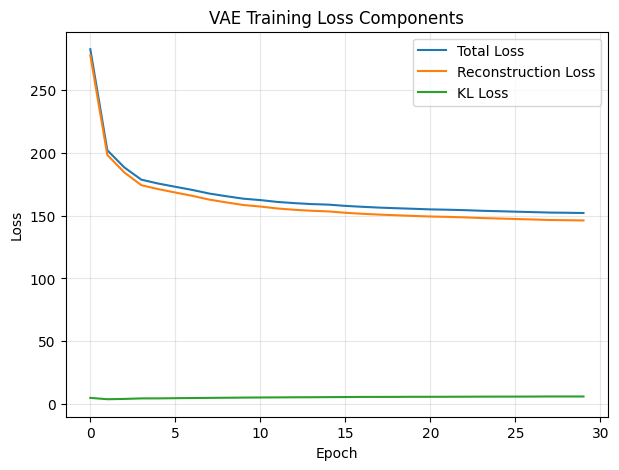

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd # Added this line

np.random.seed(42)
tf.random.set_seed(42)

data = np.load("exp7_data.npz")
x_train_cnn = data["x_train_cnn"]
x_test_cnn = data["x_test_cnn"]
y_test = data["y_test"]

LATENT_DIM = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

latent_inputs = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

history = vae.fit(
    x_train_cnn,
    epochs=30,
    batch_size=128,
    verbose=2
)

metrics = vae.evaluate(x_test_cnn, batch_size=128, verbose=0, return_dict=True)
print("Final test-set metrics:", metrics)

encoder.save("vae_encoder.keras")
decoder.save("vae_decoder.keras")
np.save("vae_history.npy", history.history)
np.save("vae_val_metrics.npy", metrics)

print("VAE training complete. Encoder and decoder saved separately.")
print(f"Final total loss: {history.history['loss'][-1]:.3f}")
print(f"Final reconstruction loss: {history.history['reconstruction_loss'][-1]:.3f}")
print(f"Final KL loss: {history.history['kl_loss'][-1]:.3f}")

# Quick loss curve
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Total Loss")
plt.plot(history.history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history.history["kl_loss"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss Components")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("vae_training_loss_components.png", dpi=150)
plt.show()

Task:15-17

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_11[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_33[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3136)      │          0 │ conv2d_34[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 16)        │     50,192 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_2          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - kl_loss: 1.4128 - loss: 294.7614 - reconstruction_loss: 293.3486 - val_kl_loss: 1.3503 - val_loss: 207.3229 - val_reconstruction_loss: 205.9726
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 2.1952 - loss: 204.9122 - reconstruction_loss: 202.7170 - val_kl_loss: 2.7010 - val_loss: 199.3696 - val_reconstruction_loss: 196.6687
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 2.9575 - loss: 199.9893 - reconstruction_loss: 197.0318 - val_kl_loss: 3.0273 - val_loss: 195.0933 - val_reconstruction_loss: 192.0660
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 3.1065 - loss: 197.7237 - reconstruction_loss: 194.6172 - val_kl_loss: 3.0989 - val_loss: 194.0912 - val_reconstruction_loss: 190.9923
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 3.1957 - loss: 195.7172 - reconstruction_loss: 192.5216 - val_kl_loss: 2.6673 - val_loss: 193.1590 - val_reconstruction_loss: 190.4917
Epoch 6/20
79/7

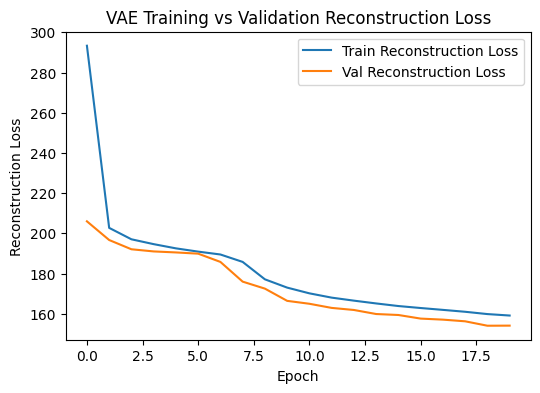

In [ ]:
LATENT_DIM_VAE = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
conv_shape = x.shape[1:]
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM_VAE, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")
vae_encoder.summary()

latent_inputs = keras.Input(shape=(LATENT_DIM_VAE,))
x = layers.Dense(conv_shape[0] * conv_shape[1] * conv_shape[2], activation="relu")(latent_inputs)
x = layers.Reshape((conv_shape[0], conv_shape[1], conv_shape[2]))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
vae_decoder = keras.Model(latent_inputs, decoder_outputs, name="vae_decoder")
vae_decoder.summary()

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

vae_history = vae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)
plt.figure(figsize=(6, 4))
plt.plot(vae_history.history["reconstruction_loss"], label="Train Reconstruction Loss")
plt.plot(vae_history.history["val_reconstruction_loss"], label="Val Reconstruction Loss")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction Loss")
plt.title("VAE Training vs Validation Reconstruction Loss"); plt.legend(); plt.show()



Task:18

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_13[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_35[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 3136)      │          0 │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 16)        │     50,192 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_3          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - kl_loss: 2.9515 - loss: 285.3963 - reconstruction_loss: 282.4448 - val_kl_loss: 2.2166 - val_loss: 207.4695 - val_reconstruction_loss: 205.2529
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 2.9139 - loss: 204.5298 - reconstruction_loss: 201.6159 - val_kl_loss: 3.3439 - val_loss: 196.8224 - val_reconstruction_loss: 193.4785
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.5539 - loss: 196.9247 - reconstruction_loss: 193.3708 - val_kl_loss: 4.2520 - val_loss: 190.8699 - val_reconstruction_loss: 186.6179
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 5.1024 - loss: 189.5401 - reconstruction_loss: 184.4377 - val_kl_loss: 5.3777 - val_loss: 183.3766 - val_reconstruction_loss: 177.9989
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 5.3184 - loss: 183.9146 - reconstruction_loss: 178.5961 - val_kl_loss: 5.2209 - val_loss: 178.4181 - val_reconstruction_loss: 173.1973
Epoch 6/20
79/79 ━

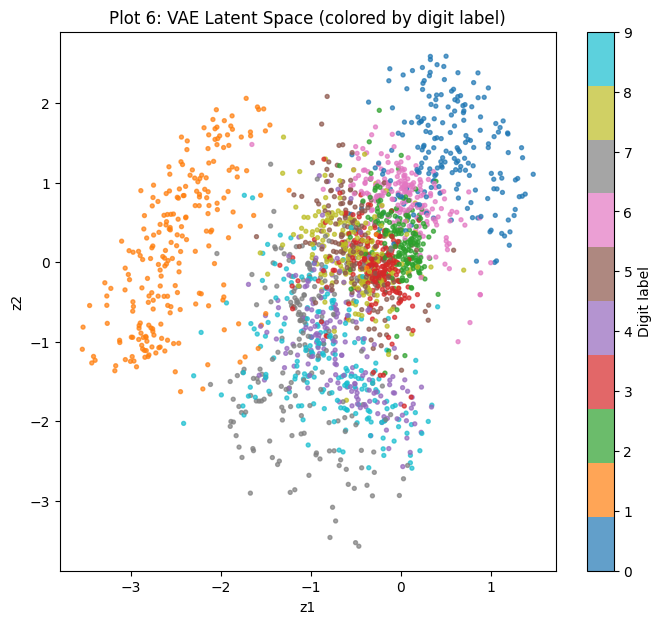

In [ ]:
LATENT_DIM_VAE = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
conv_shape = x.shape[1:]
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM_VAE, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")
vae_encoder.summary()

latent_inputs = keras.Input(shape=(LATENT_DIM_VAE,))
x = layers.Dense(conv_shape[0] * conv_shape[1] * conv_shape[2], activation="relu")(latent_inputs)
x = layers.Reshape((conv_shape[0], conv_shape[1], conv_shape[2]))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
vae_decoder = keras.Model(latent_inputs, decoder_outputs, name="vae_decoder")
vae_decoder.summary()
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

vae_history = vae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)
z_mean_test, z_log_var_test, _ = vae_encoder.predict(x_test_cnn)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, label="Digit label")
plt.xlabel("z1"); plt.ylabel("z2")
plt.title("Plot 6: VAE Latent Space (colored by digit label)")
plt.show()

Task:19

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_15[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 3136)      │          0 │ conv2d_38[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 16)        │     50,192 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_4          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - kl_loss: 1.5084 - loss: 311.1724 - reconstruction_loss: 309.6640 - val_kl_loss: 2.8506 - val_loss: 212.0627 - val_reconstruction_loss: 209.2120
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 2.7397 - loss: 211.1133 - reconstruction_loss: 208.3736 - val_kl_loss: 2.6825 - val_loss: 203.7000 - val_reconstruction_loss: 201.0176
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 2.9869 - loss: 202.4551 - reconstruction_loss: 199.4682 - val_kl_loss: 3.2831 - val_loss: 198.7046 - val_reconstruction_loss: 195.4216
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.0842 - loss: 198.8585 - reconstruction_loss: 195.7742 - val_kl_loss: 2.7691 - val_loss: 195.4736 - val_reconstruction_loss: 192.7045
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.1678 - loss: 197.2982 - reconstruction_loss: 194.1304 - val_kl_loss: 2.6905 - val_loss: 195.4671 - val_reconstruction_loss: 192.7766
Epoch 6/20
79/79 ━

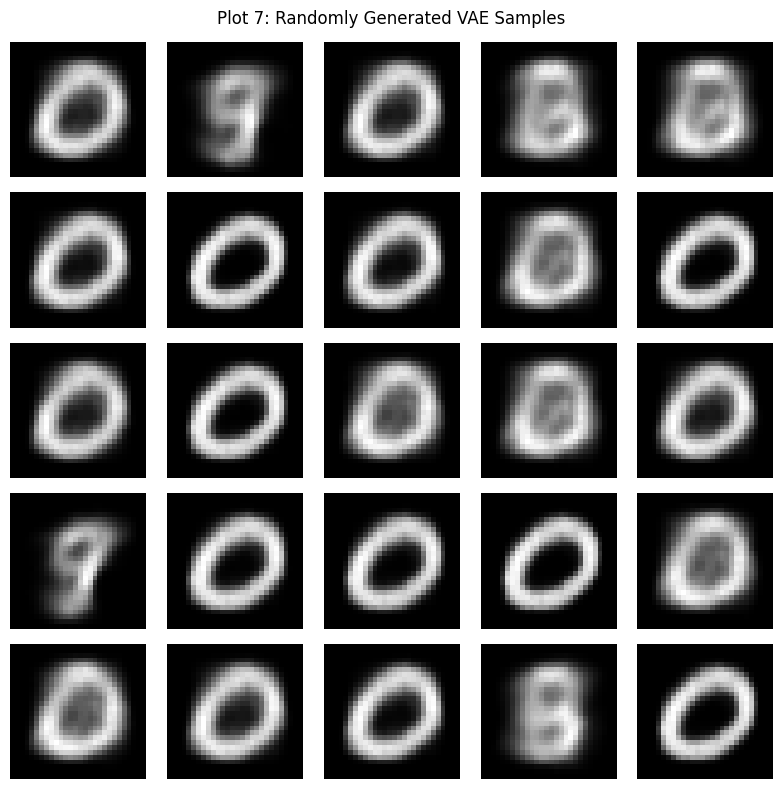

In [ ]:
LATENT_DIM_VAE = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
conv_shape = x.shape[1:]
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM_VAE, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")
vae_encoder.summary()

latent_inputs = keras.Input(shape=(LATENT_DIM_VAE,))
x = layers.Dense(conv_shape[0] * conv_shape[1] * conv_shape[2], activation="relu")(latent_inputs)
x = layers.Reshape((conv_shape[0], conv_shape[1], conv_shape[2]))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
vae_decoder = keras.Model(latent_inputs, decoder_outputs, name="vae_decoder")
vae_decoder.summary()
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

vae_history = vae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)
n_samples = 25
random_latent_vectors = np.random.normal(size=(n_samples, LATENT_DIM_VAE))
generated_images = vae_decoder.predict(random_latent_vectors)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].reshape(28, 28), cmap="gray"); ax.axis("off")
plt.suptitle("Plot 7: Randomly Generated VAE Samples")
plt.tight_layout(); plt.show()


Task:20

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_17[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 3136)      │          0 │ conv2d_40[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 16)        │     50,192 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_5          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - kl_loss: 1.3022 - loss: 294.2791 - reconstruction_loss: 292.9769 - val_kl_loss: 0.0087 - val_loss: 208.8722 - val_reconstruction_loss: 208.8636
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 0.1953 - loss: 209.8514 - reconstruction_loss: 209.6562 - val_kl_loss: 1.1387 - val_loss: 202.6171 - val_reconstruction_loss: 201.4784
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 2.4977 - loss: 199.2339 - reconstruction_loss: 196.7362 - val_kl_loss: 2.5224 - val_loss: 193.8788 - val_reconstruction_loss: 191.3564
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 2.3935 - loss: 192.9139 - reconstruction_loss: 190.5204 - val_kl_loss: 2.3676 - val_loss: 189.3282 - val_reconstruction_loss: 186.9605
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 2.2530 - loss: 189.8915 - reconstruction_loss: 187.6386 - val_kl_loss: 2.2238 - val_loss: 186.9659 - val_reconstruction_loss: 184.7422
Epoch 6/20
79/79

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


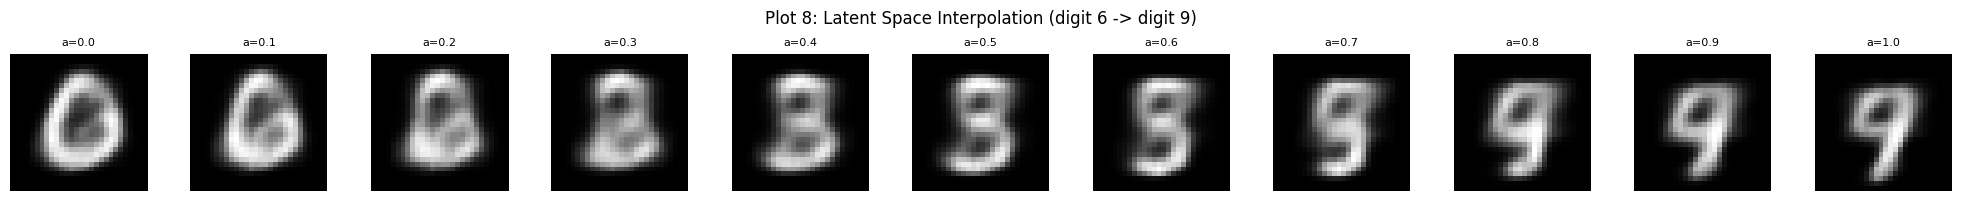

In [ ]:
LATENT_DIM_VAE = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
conv_shape = x.shape[1:]
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM_VAE, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")
vae_encoder.summary()

latent_inputs = keras.Input(shape=(LATENT_DIM_VAE,))
x = layers.Dense(conv_shape[0] * conv_shape[1] * conv_shape[2], activation="relu")(latent_inputs)
x = layers.Reshape((conv_shape[0], conv_shape[1], conv_shape[2]))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
vae_decoder = keras.Model(latent_inputs, decoder_outputs, name="vae_decoder")
vae_decoder.summary()
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

vae_history = vae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)
idx_a, idx_b = 0, 1
img_a, img_b = x_test_cnn[idx_a:idx_a+1], x_test_cnn[idx_b:idx_b+1]
z_a, _, _ = vae_encoder.predict(img_a)
z_b, _, _ = vae_encoder.predict(img_b)

alphas = np.linspace(0, 1, 11)
interpolated_z = np.array([(1 - a) * z_a[0] + a * z_b[0] for a in alphas])
interpolated_images = vae_decoder.predict(interpolated_z)

fig, axes = plt.subplots(1, len(alphas), figsize=(20, 2))
for i, ax in enumerate(axes):
    ax.imshow(interpolated_images[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"a={alphas[i]:.1f}", fontsize=8); ax.axis("off")
plt.suptitle(f"Plot 8: Latent Space Interpolation (digit {y_test[idx_a]} -> digit {y_test[idx_b]})")
plt.tight_layout(); plt.show()


Task:21

In [ ]:
def evaluate_reconstruction(x_true, x_pred):
    """x_true, x_pred: arrays of shape (N,28,28), (N,28,28,1) or (N,784), values in [0,1]."""
    x_true_flat = x_true.reshape(len(x_true), -1)
    x_pred_flat = x_pred.reshape(len(x_pred), -1)
    mse = np.mean((x_true_flat - x_pred_flat) ** 2)
    mae = np.mean(np.abs(x_true_flat - x_pred_flat))
    x_true_img = x_true.reshape(len(x_true), 28, 28)
    x_pred_img = x_pred.reshape(len(x_pred), 28, 28)
    ssim_scores = [ssim(x_true_img[i], x_pred_img[i], data_range=1.0) for i in range(len(x_true_img))]
    return {"MSE": mse, "MAE": mae, "SSIM": np.mean(ssim_scores)}

def build_fc_autoencoder(latent_dim=16):
    inputs = keras.Input(shape=(784,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(latent)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(784, activation="sigmoid")(x)
    autoencoder = keras.Model(inputs, outputs, name="fc_autoencoder")
    encoder = keras.Model(inputs, latent, name="fc_encoder")
    return autoencoder, encoder

fc_autoencoder, fc_encoder = build_fc_autoencoder(latent_dim=16)
fc_autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
fc_autoencoder.summary()

fc_history = fc_autoencoder.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20, batch_size=128, verbose=1
)
def build_conv_autoencoder():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder")
    encoder = keras.Model(inputs, encoded, name="conv_encoder")
    return autoencoder, encoder

cae, cae_encoder = build_conv_autoencoder()
cae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
cae.summary()

cae_history = cae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)
def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(loc=0.0, scale=sigma, size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype("float32")

def add_salt_pepper_noise(images, p):
    noisy = images.copy()
    mask = np.random.random(images.shape)
    noisy[mask < (p / 2)] = 0.0
    noisy[(mask >= (p / 2)) & (mask < p)] = 1.0
    return noisy.astype("float32")

SIGMA_TRAIN = 0.2
x_train_noisy = add_gaussian_noise(x_train_cnn, SIGMA_TRAIN)
x_test_noisy = add_gaussian_noise(x_test_cnn, SIGMA_TRAIN)

denoise_cae, denoise_encoder = build_conv_autoencoder()
denoise_cae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")

denoise_history = denoise_cae.fit(
    x_train_noisy, x_train_cnn,
    validation_data=(x_test_noisy, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)
LATENT_DIM_VAE = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
conv_shape = x.shape[1:]
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM_VAE, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")
vae_encoder.summary()

latent_inputs = keras.Input(shape=(LATENT_DIM_VAE,))
x = layers.Dense(conv_shape[0] * conv_shape[1] * conv_shape[2], activation="relu")(latent_inputs)
x = layers.Reshape((conv_shape[0], conv_shape[1], conv_shape[2]))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
vae_decoder = keras.Model(latent_inputs, decoder_outputs, name="vae_decoder")
vae_decoder.summary()
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

vae_history = vae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)

fc_test_recon = fc_autoencoder.predict(x_test_flat)
cae_test_recon = cae.predict(x_test_cnn)
denoised_test = denoise_cae.predict(x_test_noisy)
z_mean_test, _, _ = vae_encoder.predict(x_test_cnn)
vae_recon_test = vae_decoder.predict(z_mean_test)

fc_metrics = evaluate_reconstruction(x_test_flat, fc_test_recon); fc_metrics["Parameters"] = fc_autoencoder.count_params()
cae_metrics = evaluate_reconstruction(x_test_cnn, cae_test_recon); cae_metrics["Parameters"] = cae.count_params()
denoise_metrics = evaluate_reconstruction(x_test_cnn, denoised_test); denoise_metrics["Parameters"] = denoise_cae.count_params()
vae_metrics = evaluate_reconstruction(x_test_cnn, vae_recon_test); vae_metrics["Parameters"] = vae_encoder.count_params() + vae_decoder.count_params()

vae_eval = vae.evaluate(x_test_cnn, x_test_cnn, verbose=0, return_dict=True)

full_comparison_df = pd.DataFrame([
    {"Model": "Fully Connected AE", **fc_metrics},
    {"Model": "Convolutional AE", **cae_metrics},
    {"Model": "Denoising CAE", **denoise_metrics},
    {"Model": "VAE", **vae_metrics},
])
print(full_comparison_df.to_string(index=False))

print("\nVAE loss breakdown:")
print(f"  Reconstruction Loss: {vae_eval['reconstruction_loss']:.4f}")
print(f"  KL Loss:             {vae_eval['kl_loss']:.4f}")
print(f"  Total Loss:          {vae_eval['loss']:.4f}")

Model: "fc_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - kl_loss: 0.5016 - loss: 301.3489 - reconstruction_loss: 300.8474 - val_kl_loss: 0.0277 - val_loss: 210.4575 - val_reconstruction_loss: 210.4298
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 0.0141 - loss: 210.5965 - reconstruction_loss: 210.5824 - val_kl_loss: 0.0115 - val_loss: 206.4900 - val_reconstruction_loss: 206.4785
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 0.4186 - loss: 207.1196 - reconstruction_loss: 206.7010 - val_kl_loss: 1.2751 - val_loss: 200.6216 - val_reconstruction_loss: 199.3465
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 1.9969 - loss: 201.8001 - reconstruction_loss: 199.8033 - val_kl_loss: 2.5021 - val_loss: 196.8293 - val_reconstruction_loss: 194.3272
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 2.9142 - loss: 197.9100 - reconstruction_loss: 194.9958 - val_kl_loss: 3.0876 - val_loss: 193.3979 - val_reconstruction_loss: 190.3103
Epoch 6/20
79/79 ━

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
             Model      MSE      MAE     SSIM  Parameters
Fully Connected AE 0.022427 0.058893 0.734007      211040
  Convolutional AE 0.002496 0.014989 0.974557       74497
     Denoising CAE 0.004464 0.020984 0.948066       74497
               VAE 0.054330 0.124119 0.367369      134165

VAE loss breakdown:
  Reconstruction Loss: 171.5970
  KL Loss:             3.4976
  Total Loss:          175.0946


Task:22-24

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_16 (UpSampling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_17 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.2334 - val_loss: 0.1052
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0931 - val_loss: 0.0844
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0821 - val_loss: 0.0799
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0783 - val_loss: 0.0775
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0761 - val_loss: 0.0746
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0746 - val_loss: 0.0734
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0735 - val_loss: 0.0735
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0727 - val_loss: 0.0718
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0719 - val_loss: 0.0716
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0713 - val_loss: 0.0718
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0708 - val_loss: 0.0702
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0703 - val_

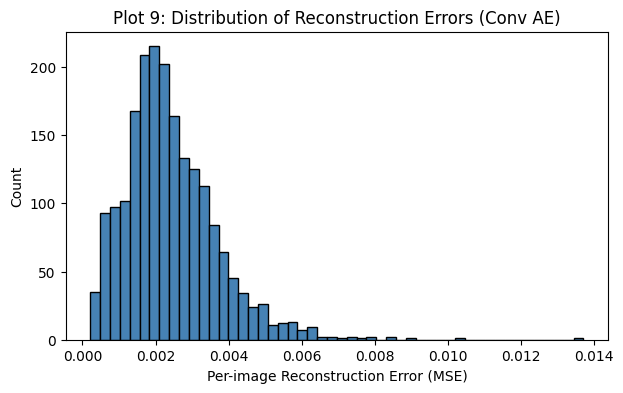

Mean error: 0.00241 | Std: 0.00127
Min: 0.00021 | Max: 0.01371


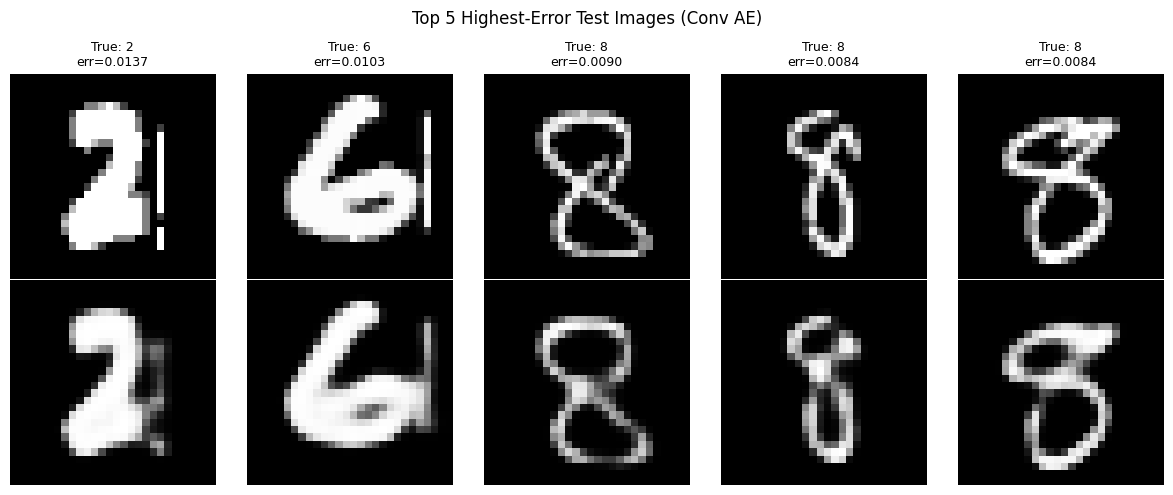

In [ ]:
def evaluate_reconstruction(x_true, x_pred):
    """x_true, x_pred: arrays of shape (N,28,28), (N,28,28,1) or (N,784), values in [0,1]."""
    x_true_flat = x_true.reshape(len(x_true), -1)
    x_pred_flat = x_pred.reshape(len(x_pred), -1)
    mse = np.mean((x_true_flat - x_pred_flat) ** 2)
    mae = np.mean(np.abs(x_true_flat - x_pred_flat))
    x_true_img = x_true.reshape(len(x_true), 28, 28)
    x_pred_img = x_pred.reshape(len(x_pred), 28, 28)
    ssim_scores = [ssim_metric(x_true_img[i], x_pred_img[i], data_range=1.0) for i in range(len(x_true_img))]
    return {"MSE": mse, "MAE": mae, "SSIM": np.mean(ssim_scores)}
def build_conv_autoencoder():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder")
    encoder = keras.Model(inputs, encoded, name="conv_encoder")
    return autoencoder, encoder

cae, cae_encoder = build_conv_autoencoder()
cae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
cae.summary()

cae_history = cae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=1
)
cae_test_recon = cae.predict(x_test_cnn)
per_image_mse = np.mean(
    (x_test_cnn.reshape(len(x_test_cnn), -1) - cae_test_recon.reshape(len(cae_test_recon), -1)) ** 2, axis=1
)

plt.figure(figsize=(7, 4))
plt.hist(per_image_mse, bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Per-image Reconstruction Error (MSE)"); plt.ylabel("Count")
plt.title("Plot 9: Distribution of Reconstruction Errors (Conv AE)")
plt.show()

print(f"Mean error: {per_image_mse.mean():.5f} | Std: {per_image_mse.std():.5f}")
print(f"Min: {per_image_mse.min():.5f} | Max: {per_image_mse.max():.5f}")
worst_idx = np.argsort(per_image_mse)[-5:][::-1]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for col, idx in enumerate(worst_idx):
    axes[0, col].imshow(x_test_cnn[idx].reshape(28, 28), cmap="gray")
    axes[0, col].set_title(f"True: {y_test[idx]}\nerr={per_image_mse[idx]:.4f}", fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(cae_test_recon[idx].reshape(28, 28), cmap="gray")
    axes[1, col].axis("off")
plt.suptitle("Top 5 Highest-Error Test Images (Conv AE)")
plt.tight_layout(); plt.show()

Task-27

Latent dim 2: MSE=0.05950, SSIM=0.2720
Latent dim 8: MSE=0.03821, SSIM=0.5601
Latent dim 16: MSE=0.02682, SSIM=0.6788
Latent dim 32: MSE=0.02380, SSIM=0.7103
 Latent Dimension      MSE     SSIM  Parameters
                2 0.059498 0.272002      210130
                8 0.038209 0.560091      210520
               16 0.026819 0.678831      211040
               32 0.023802 0.710337      212080


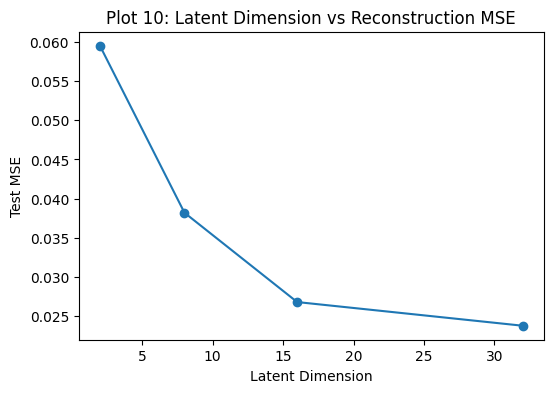

In [ ]:
def evaluate_reconstruction(x_true, x_pred):
    """x_true, x_pred: arrays of shape (N,28,28), (N,28,28,1) or (N,784), values in [0,1]."""
    x_true_flat = x_true.reshape(len(x_true), -1)
    x_pred_flat = x_pred.reshape(len(x_pred), -1)
    mse = np.mean((x_true_flat - x_pred_flat) ** 2)
    mae = np.mean(np.abs(x_true_flat - x_pred_flat))
    x_true_img = x_true.reshape(len(x_true), 28, 28)
    x_pred_img = x_pred.reshape(len(x_pred), 28, 28)
    ssim_scores = [ssim(x_true_img[i], x_pred_img[i], data_range=1.0) for i in range(len(x_true_img))]
    return {"MSE": mse, "MAE": mae, "SSIM": np.mean(ssim_scores)}
def build_fc_autoencoder(latent_dim=16):
    inputs = keras.Input(shape=(784,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(latent)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(784, activation="sigmoid")(x)
    autoencoder = keras.Model(inputs, outputs, name="fc_autoencoder")
    encoder = keras.Model(inputs, latent, name="fc_encoder")
    return autoencoder, encoder

latent_dims_to_try = [2, 8, 16, 32]
latent_dim_results = []

for dim in latent_dims_to_try:
    model, _ = build_fc_autoencoder(latent_dim=dim)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    model.fit(x_train_flat, x_train_flat, epochs=10, batch_size=128, verbose=0,
              validation_data=(x_test_flat, x_test_flat))
    recon = model.predict(x_test_flat, verbose=0)
    metrics = evaluate_reconstruction(x_test_flat, recon)
    metrics["Latent Dimension"] = dim
    metrics["Parameters"] = model.count_params()
    latent_dim_results.append(metrics)
    print(f"Latent dim {dim}: MSE={metrics['MSE']:.5f}, SSIM={metrics['SSIM']:.4f}")

latent_dim_df = pd.DataFrame(latent_dim_results)[["Latent Dimension", "MSE", "SSIM", "Parameters"]]
print(latent_dim_df.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.plot(latent_dim_df["Latent Dimension"], latent_dim_df["MSE"], marker="o")
plt.xlabel("Latent Dimension"); plt.ylabel("Test MSE")
plt.title("Plot 10: Latent Dimension vs Reconstruction MSE")
plt.show()